In [1]:
import pandas as pd
import gridstatus

caiso = gridstatus.CAISO()

start = pd.Timestamp("2023-01-23", tz="PST8PDT")
end   = pd.Timestamp("2024-12-31", tz="PST8PDT")

parts = []
cur = start.normalize()  # force 00:00
while cur < end:
    nxt = min(cur + pd.Timedelta(days=7), end)
    try:
        part = caiso.get_lmp(
            date=cur,
            end=nxt,
            market="DAY_AHEAD_HOURLY",
            locations=["TH_NP15_GEN-APND"],   # if empty, try TH_NP15_GEN
        )
        if part is not None and len(part):
            parts.append(part)
    except Exception as e:
        print(f"Chunk failed: {cur} to {nxt} -> {e}")
    cur = nxt

lmp_chunked = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
print(lmp_chunked.head(), len(lmp_chunked))


lmp_df=lmp_chunked.copy()


# convert Time column to pandas datetime (timezone-aware)
lmp_df["Time"] = pd.to_datetime(lmp_df["Time"])


print(lmp_df.dtypes)
print(lmp_df.head())

2026-05-18 16:11:50 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-18 16:11:50 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20230123T08:00-0000&enddatetime=20230130T08:00-0000
2026-05-18 16:11:56 - WARNING - No data for 2023-01-23 00:00:00-08:00 to 2023-01-30 00:00:00-08:00
2026-05-18 16:11:56 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-18 16:11:56 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20230130T08:00-0000&endda

Error: No data found for start date: 2023-01-23 00:00:00-08:00 and end date: 2023-01-30 00:00:00-08:00
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x000001CC124AA000>, 'date': Timestamp('2023-01-23 00:00:00-0800', tz='US/Pacific'), 'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>, 'locations': ['TH_NP15_GEN-APND'], 'end': Timestamp('2023-01-30 00:00:00-0800', tz='US/Pacific')}

Errors that occurred while getting data:
[{'date': Timestamp('2023-01-23 00:00:00-0800', tz='US/Pacific'),
  'end': Timestamp('2023-01-30 00:00:00-0800', tz='US/Pacific'),
  'locations': ['TH_NP15_GEN-APND'],
  'market': <Markets.DAY_AHEAD_HOURLY: 'DAY_AHEAD_HOURLY'>,
  'self': <gridstatus.caiso.caiso.CAISO object at 0x000001CC124AA000>}]
Chunk failed: 2023-01-23 00:00:00-08:00 to 2023-01-30 00:00:00-08:00 -> No objects to concatenate


2026-05-18 16:11:57 - DEBUG - Found 1 files: ['20230130_20230206_PRC_LMP_DAM_20260518_13_11_56_v12.csv']
2026-05-18 16:11:57 - DEBUG - Parsing file: 20230130_20230206_PRC_LMP_DAM_20260518_13_11_56_v12.csv
2026-05-18 16:12:02 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-05-18 16:12:02 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20230206T08:00-0000&enddatetime=20230213T08:00-0000
2026-05-18 16:12:03 - DEBUG - Found 1 files: ['20230206_20230213_PRC_LMP_DAM_20260518_13_12_02_v12.csv']
2026-05-18 16:12:03 - DEBUG - Parsing file: 20230206_20230213_PRC_LMP_DAM_20260518_13_12_02_v12.csv
2026-05-18 16:12:08 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'vers

                       Time            Interval Start  \
0 2023-02-02 00:00:00-08:00 2023-02-02 00:00:00-08:00   
1 2023-02-02 01:00:00-08:00 2023-02-02 01:00:00-08:00   
2 2023-02-02 02:00:00-08:00 2023-02-02 02:00:00-08:00   
3 2023-02-02 03:00:00-08:00 2023-02-02 03:00:00-08:00   
4 2023-02-02 04:00:00-08:00 2023-02-02 04:00:00-08:00   

               Interval End            Market          Location Location Type  \
0 2023-02-02 01:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
1 2023-02-02 02:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
2 2023-02-02 03:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
3 2023-02-02 04:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   
4 2023-02-02 05:00:00-08:00  DAY_AHEAD_HOURLY  TH_NP15_GEN-APND   Trading Hub   

         LMP     Energy  Congestion     Loss  
0  136.84110  142.40930         0.0 -5.56820  
1  136.57455  142.16151         0.0 -5.58695  
2  132.91270  138.19162      

In [2]:
start = pd.Timestamp("2023-01-23", tz="PST8PDT")
end   = pd.Timestamp("2024-12-31", tz="PST8PDT")
print(start.normalize())

2023-01-23 00:00:00-08:00


In [3]:
lmp_df.head()

,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss
0,2023-02-02 00:00:00-08:00,2023-02-02 00:00:00-08:00,2023-02-02 01:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,136.84110,142.40930,0.0,-5.56820
1,2023-02-02 01:00:00-08:00,2023-02-02 01:00:00-08:00,2023-02-02 02:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,136.57455,142.16151,0.0,-5.58695
2,2023-02-02 02:00:00-08:00,2023-02-02 02:00:00-08:00,2023-02-02 03:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,132.91270,138.19162,0.0,-5.27892
3,2023-02-02 03:00:00-08:00,2023-02-02 03:00:00-08:00,2023-02-02 04:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,137.52002,142.89279,0.0,-5.37277
4,2023-02-02 04:00:00-08:00,2023-02-02 04:00:00-08:00,2023-02-02 05:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,144.05095,149.94373,0.0,-5.89279


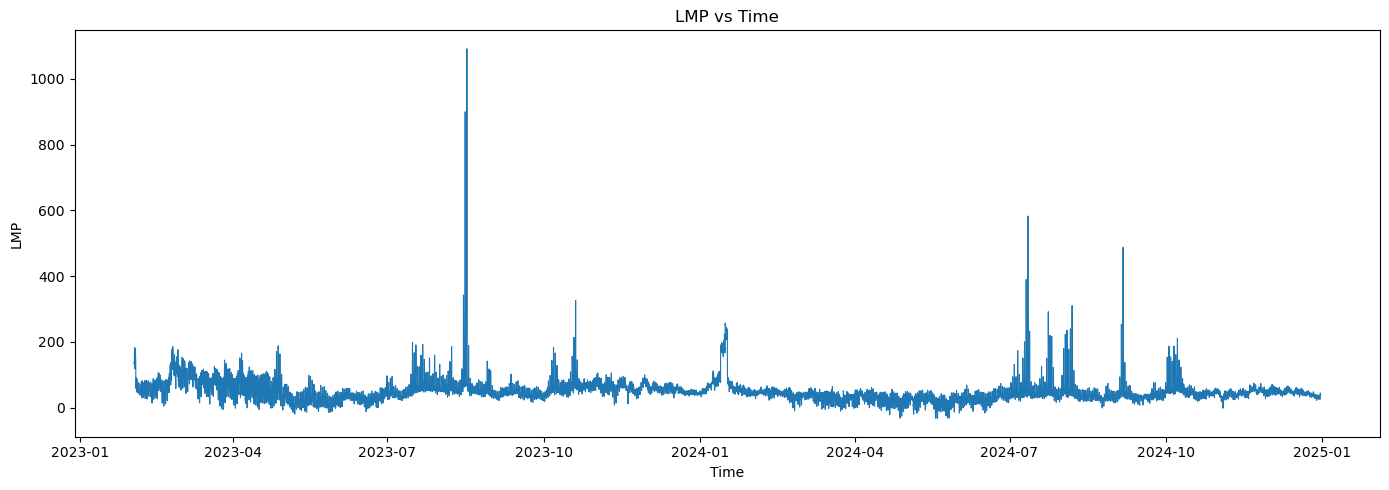

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# choose your time column in lmp_df (commonly "Time" or "Interval Start")
time_col = "Time"   # change if needed

lmp_df[time_col] = pd.to_datetime(lmp_df[time_col])
lmp_df = lmp_df.sort_values(time_col)

plt.figure(figsize=(14, 5))
plt.plot(lmp_df[time_col], lmp_df["LMP"], linewidth=0.8)
plt.xlabel(time_col)
plt.ylabel("LMP")
plt.title(f"LMP vs {time_col}")
plt.tight_layout()
plt.show()

In [5]:
import requests
import pandas as pd

# 1-day before weather forecasts
url = "https://previous-runs-api.open-meteo.com/v1/forecast"
params = {
    # 2107 Arbuckle, CA location
    "latitude": 38.9963,
    "longitude": -122.1341,
    "start_date": "2022-03-23",
    "end_date": "2024-10-31",
    "timezone": "PST8PDT",  # set local timezone
    # Use 'minutely_15' instead of 'hourly'
    "minutely_15": [
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "wind_speed_10m",
        "wind_speed_80m",
        "wind_direction_10m",
        "wind_direction_80m",
        "wind_gusts_10m",
        "shortwave_radiation",
        "direct_radiation",
        "direct_normal_irradiance",
        "diffuse_radiation",
        "global_tilted_irradiance",
        "sunshine_duration",
        "precipitation",
        "snowfall",
        "rain",
        "cape",
        "visibility",
        "weather_code",
        "cloud_cover",
        "pressure_msl",
        "surface_pressure"
    ], 
    "models": "gfs_seamless",
    "previous_day": 1 
}

data = requests.get(url, params=params).json()
weather_df = pd.DataFrame(data['minutely_15']).rename(columns={"time": "measured_on"})

###########################
# Modify the file path used by pd.read_csv()


# meter_train date range: 2017-01-01 - 2023/11/09
meter_train = pd.read_csv("2107_data/2107_meter_15m_data.csv")

col = "meter_revenue_grade_ac_output_meter_149578"
meter_train = meter_train[meter_train[col] <= 1000].copy()



# meter_2024 date range: 2024/01/01 - 2024/10/31
meter_2024 = pd.read_csv("2107_data/2107_meter_15m_data_2024.csv")

# ensure same datetime type
weather_df["measured_on"] = pd.to_datetime(weather_df["measured_on"])
meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_2024["measured_on"] = pd.to_datetime(meter_2024["measured_on"])


# df_train date range: 2022/03/23 - 2023/11/09
df_train = meter_train.merge(weather_df, on="measured_on", how="left").dropna()
# df_2024 date range: 2024/01/01 - 2024/10/31
df_2024 = meter_2024.merge(weather_df, on="measured_on", how="outer").dropna()

val_end = pd.Timestamp("2024-05-31 23:59:59")
# df_val date range: 2024-01-01 - 2024-05-31
df_val = df_2024[df_2024["measured_on"] <= val_end].copy()
# df_test date range: 2024-06-01 - 2024-10-31
df_test = df_2024[df_2024["measured_on"] > val_end].copy()

# Use df_train, df_val, df_test for train, validation(walk forward validation) and test.
print(df_train.head())

               measured_on  meter_revenue_grade_ac_output_meter_149578  \
182854 2022-03-23 00:00:00                                         0.0   
182855 2022-03-23 00:15:00                                         0.0   
182856 2022-03-23 00:30:00                                         0.0   
182857 2022-03-23 00:45:00                                         0.0   
182858 2022-03-23 01:00:00                                         0.0   

        temperature_2m  relative_humidity_2m  dew_point_2m  \
182854            21.0                  30.0           2.7   
182855            20.8                  30.0           2.6   
182856            20.5                  31.0           2.8   
182857            20.2                  32.0           3.0   
182858            19.7                  33.0           3.0   

        apparent_temperature  wind_speed_10m  wind_speed_80m  \
182854                  16.9            16.6            19.2   
182855                  16.8            15.8          

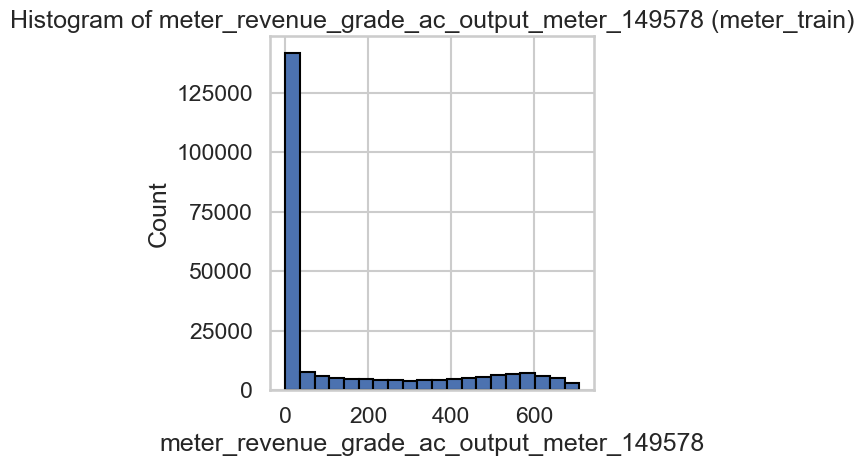

In [27]:
import matplotlib.pyplot as plt

col = "meter_revenue_grade_ac_output_meter_149578"

plt.figure(figsize=(5, 5))
plt.hist(meter_train[col].dropna(), bins=20, edgecolor="black")
plt.xlabel(col)
plt.ylabel("Count")
plt.title(f"Histogram of {col} (meter_train)")
plt.tight_layout()
plt.show()

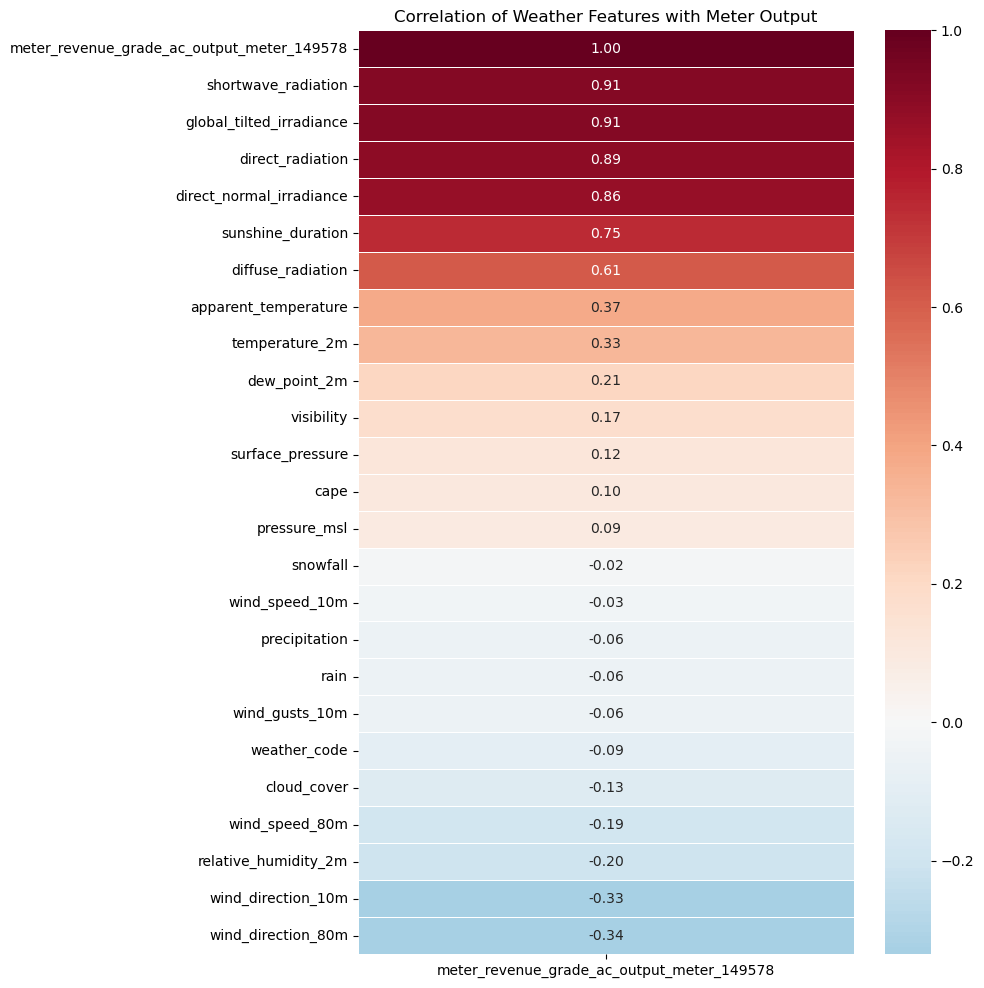

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# We exclude 'measured_on' because it is a datetime object
corr_matrix = df_train.drop(columns=['measured_on']).corr()

# 2. Isolate correlation with the target only
target_col = 'meter_revenue_grade_ac_output_meter_149578'
target_corr = corr_matrix[[target_col]].sort_values(by=target_col, ascending=False)

# 3. Create the Heatmap
plt.figure(figsize=(8, 12))
sns.heatmap(target_corr, 
            annot=True,      # Show the numbers
            cmap='RdBu_r',   # Red for positive, Blue for negative correlation
            center=0,        # 0 is the neutral point (white)
            fmt=".2f",       # 2 decimal places
            linewidths=0.5)

plt.title('Correlation of Weather Features with Meter Output')
plt.savefig('feature_correlation_heatmap.png', bbox_inches='tight')

In [7]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse
import numpy as np
import pandas as pd

# Add baseline models to meter_train and meter_2024 to find out baseline MWOL


target = "meter_revenue_grade_ac_output_meter_149578"

meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_train = meter_train.sort_values("measured_on").reset_index(drop=True)

steps_per_day = 96
lags = [steps_per_day * d for d in range(1, 4)]  # 1..3 days ago

meter_train["yhat_baseline"] = pd.concat(
    [meter_train[target].shift(l) for l in lags],
    axis=1
).mean(axis=1)

# keep only aligned columns
meter_train = meter_train[["measured_on", target, "yhat_baseline"]].copy()

# evaluate on rows where baseline exists
eval_df = meter_train.dropna(subset=[target, "yhat_baseline"])
mae_baseline = mae(eval_df[target], eval_df["yhat_baseline"])
rmse_baseline = np.sqrt(mse(eval_df[target], eval_df["yhat_baseline"]))

#print(meter_train[["measured_on", target, "yhat_baseline"]].head(10))
print(f"Baseline model: train MAE:  {mae_baseline:.4f}")
print(f"Baseline model: train RMSE: {rmse_baseline:.4f}")

# Apply the same 7-day same-time baseline to meter_2024
target = "meter_revenue_grade_ac_output_meter_149578"

meter_2024["measured_on"] = pd.to_datetime(meter_2024["measured_on"])
meter_2024 = meter_2024.sort_values("measured_on").reset_index(drop=True)

steps_per_day = 96
lags = [steps_per_day * d for d in range(1, 4)]  # 1..3 days ago

meter_2024["yhat_baseline"] = pd.concat(
    [meter_2024[target].shift(l) for l in lags],
    axis=1
).mean(axis=1)


# Optional evaluation
eval_2024 = meter_2024.dropna(subset=[target, "yhat_baseline"])
mae_baseline_2024 = mae(eval_2024[target], eval_2024["yhat_baseline"])
rmse_baseline_2024 = np.sqrt(mse(eval_2024[target], eval_2024["yhat_baseline"]))

#print(meter_2024[["measured_on", target, "yhat_baseline"]].head(20))
print(f"Baseline model: 2024 MAE:  {mae_baseline_2024:.4f}")
print(f"Baseline model: 2024 RMSE: {rmse_baseline_2024:.4f}")

Baseline model: train MAE:  39.5323
Baseline model: train RMSE: 88.3940
Baseline model: 2024 MAE:  37.0466
Baseline model: 2024 RMSE: 91.8166


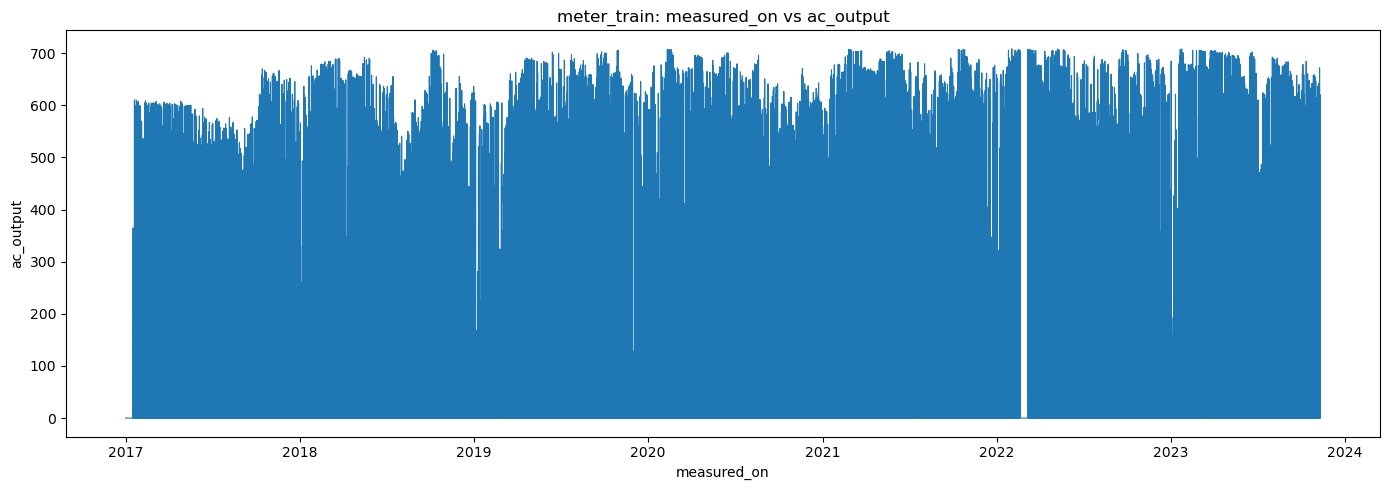

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

target = "meter_revenue_grade_ac_output_meter_149578"

meter_train["measured_on"] = pd.to_datetime(meter_train["measured_on"])
meter_train = meter_train.sort_values("measured_on")

plt.figure(figsize=(14, 5))
plt.plot(meter_train["measured_on"], meter_train[target], linewidth=0.8)
plt.xlabel("measured_on")
plt.ylabel("ac_output")
plt.title("meter_train: measured_on vs ac_output")
plt.tight_layout()
plt.show()

Based on the correlation heatmap, we would like to choose the following features in our weather data: global_tilted_irradiance, sunshine_duration, temperature_2m, cloud_cover, relative_humidity_2m, wind_speed_10m. Below is a pairplot for the three most important features.

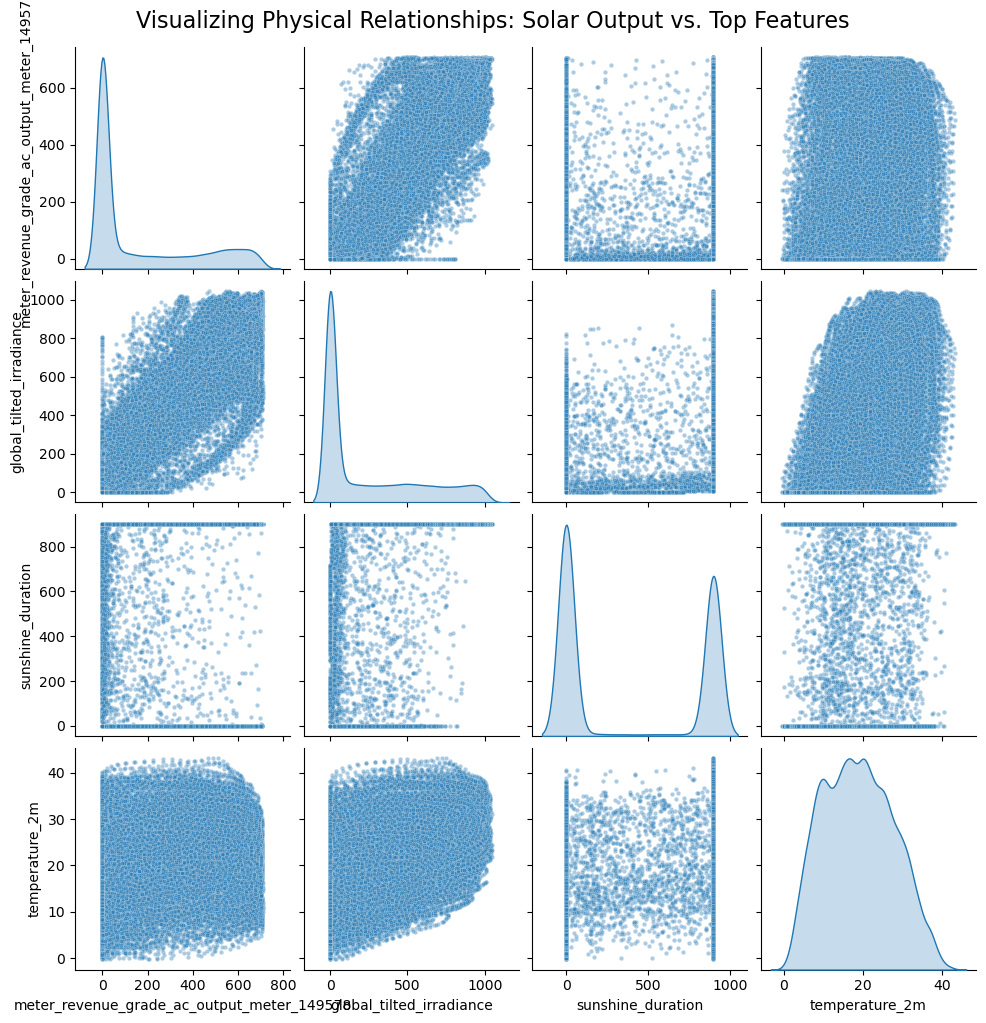

In [9]:
# Define the columns (Correcting 'radiation' to 'irradiance' based on your index)
cols_to_plot = [
    'meter_revenue_grade_ac_output_meter_149578', 
    'global_tilted_irradiance', 
    'sunshine_duration', 
    'temperature_2m'
]

# Create the pairplot
# diag_kind='kde' shows the distribution of each variable on the diagonal
# alpha=0.5 makes the dots semi-transparent so you can see where they overlap
g = sns.pairplot(df_train[cols_to_plot], 
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.4, 's': 10, 'color': '#2c7fb8'})

g.fig.suptitle('Visualizing Physical Relationships: Solar Output vs. Top Features', y=1.02, fontsize=16)

# Save the plot
plt.savefig('solar_top_features_pairplot.png', bbox_inches='tight')

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

feature_cols = ["global_tilted_irradiance", "sunshine_duration", "temperature_2m", "cloud_cover", "relative_humidity_2m", "wind_speed_10m"]
target = "meter_revenue_grade_ac_output_meter_149578"

def multiply_cols(X):
    if hasattr(X, "values"):
        X = X.values
    return (X[:, 0] * X[:, 1]).reshape(-1,1)

ct1_scaled = ColumnTransformer([('scaling', StandardScaler(), feature_cols)], remainder='drop')
ct2 = ColumnTransformer([('pass', 'passthrough', feature_cols), ('irr_squared', FunctionTransformer(np.square), ['global_tilted_irradiance']),
                               ('irr_temp_interaction', FunctionTransformer(multiply_cols), ['global_tilted_irradiance','temperature_2m']),
                               ('irr_hum_interaction', FunctionTransformer(multiply_cols), ['global_tilted_irradiance','relative_humidity_2m']),
                               ('irr_wind_interaction', FunctionTransformer(multiply_cols), ['global_tilted_irradiance','wind_speed_10m'])], remainder='drop')

models = {"linear": Pipeline([('prep',ct1_scaled), ('regressor',LinearRegression())]),
          "interaction_model": Pipeline([('prep',ct2), ('scaler', StandardScaler()), ('regressor',LinearRegression())]),
    "random_forest": Pipeline([('prep',ct1_scaled), ('regressor',RandomForestRegressor(n_estimators=100, random_state=137, n_jobs=-1))])
}

mae_train_results = []
mse_train_results = []
mae_val_results = []
mse_val_results = []
mae_test_results = []
mse_test_results = []

for name, model in models.items():
    model.fit(df_train[feature_cols], df_train[target])
    y_train = model.predict(df_train[feature_cols])
    y_val = model.predict(df_val[feature_cols])
    y_test = model.predict(df_test[feature_cols])

    mae_train = mae(df_train[target], y_train)
    mse_train = mse(df_train[target], y_train)
    mae_val = mae(df_val[target], y_val)
    mse_val = mse(df_val[target], y_val)
    mae_test = mae(df_test[target], y_test)
    mse_test = mse(df_test[target], y_test)
    mae_train_results.append((name, f"train mae is {mae_train}"))
    mse_train_results.append((name, f"train mse is {mse_train}"))
    mae_val_results.append((name, f"validation mae is {mae_val}"))
    mse_val_results.append((name, f"validation mse is {mse_val}"))
    mae_test_results.append((name, f"test mae is {mae_test}"))
    mse_test_results.append((name, f"test mse is {mse_test}"))
    

In [11]:
print(mae_train_results)
print(mse_train_results)
print(mae_val_results)
print(mse_val_results)
print(mae_test_results)
print(mse_test_results)
print(mae_baseline, rmse_baseline)
print(mae_baseline_2024, rmse_baseline_2024)

[('linear', 'train mae is 59.98885508139597'), ('interaction_model', 'train mae is 52.91108132805688'), ('random_forest', 'train mae is 13.139536358199488')]
[('linear', 'train mse is 8108.45409708503'), ('interaction_model', 'train mse is 7449.414629604403'), ('random_forest', 'train mse is 640.0901454343206')]
[('linear', 'validation mae is 58.6356210816771'), ('interaction_model', 'validation mae is 54.671008366157245'), ('random_forest', 'validation mae is 47.759340398393874')]
[('linear', 'validation mse is 8871.617507607596'), ('interaction_model', 'validation mse is 8771.129075466826'), ('random_forest', 'validation mse is 8618.908999982763')]
[('linear', 'test mae is 40.45782991192196'), ('interaction_model', 'test mae is 37.60234137508897'), ('random_forest', 'test mae is 31.953567137850268')]
[('linear', 'test mse is 4224.151327041798'), ('interaction_model', 'test mse is 3976.638481660409'), ('random_forest', 'test mse is 4334.085993998801')]
39.53229113449045 88.39403045286

Let us plot our solar panel predictions for August 2024 with the our linear regression and random forest models, together with our baseline model.

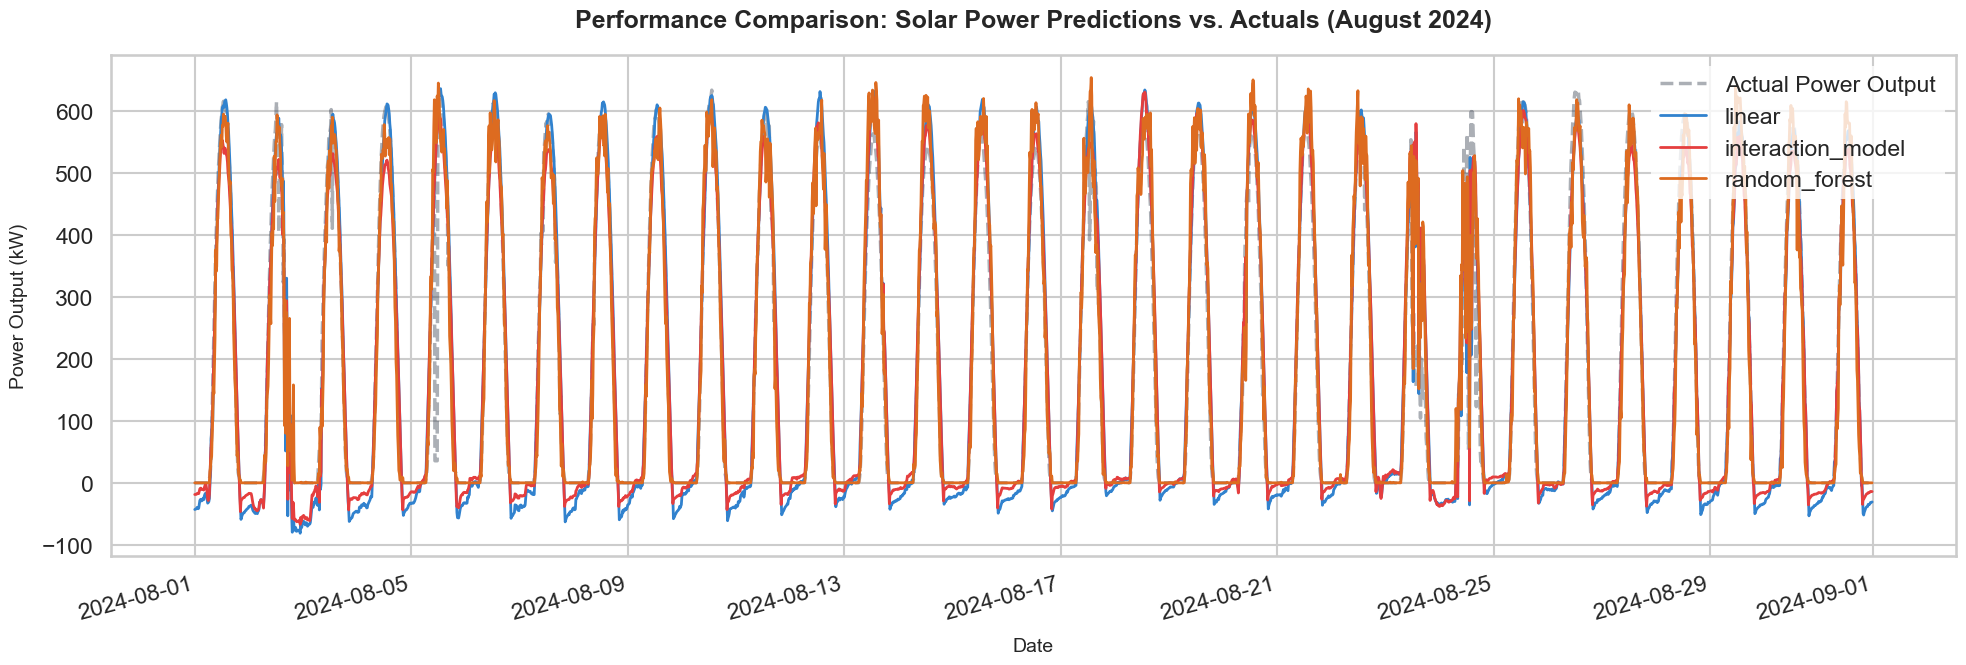

In [12]:
import seaborn as sns

# our plot covers the prediction from 8/1/2024-8/31/2024
start_time = pd.Timestamp("2024-08-01 00:00:00")
end_time = pd.Timestamp("2024-08-31 23:59:59")

# pick out the rows in df_test that is in August 2024
august_df = df_test[(df_test["measured_on"]>=start_time) & (df_test["measured_on"]<=end_time)]

sns.set_theme(style="whitegrid", context="talk") 
plt.figure(figsize=(20, 7))

# 2. Plot the actual real-world values first
sns.lineplot(
    data=august_df, 
    x="measured_on",
    y="meter_revenue_grade_ac_output_meter_149578", 
    label="Actual Power Output", 
    color="#2d3748",       # Dark slate gray
    linewidth=2.5,
    alpha=0.4,             # Semi-transparent
    linestyle="--"
)

colors = ["#3182ce", "#e53e3e", "#dd6b20"]

# generate prediction for each model
for (name, model), color in zip(models.items(), colors):
    sns.lineplot(x=august_df["measured_on"], y=model.predict(august_df[feature_cols]),
        label=name, 
        color=color,
        linewidth=2)

plt.title("Performance Comparison: Solar Power Predictions vs. Actuals (August 2024)", fontsize=18, pad=20, weight="bold")
plt.xlabel("Date", fontsize=14, labelpad=10)
plt.ylabel("Power Output (kW)", fontsize=14, labelpad=10)

# Clean up how the date labels look on the wide X-axis
plt.xticks(rotation=15, ha="right")

# Move the legend outside or to an empty corner so it doesn't cover data points
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

# Tighten layout boundaries and display
plt.tight_layout()
plt.show()

Total MWOL: $6,396.14
Mean Daily MWOL: $22.84/day
Financial Efficiency: 85.27%


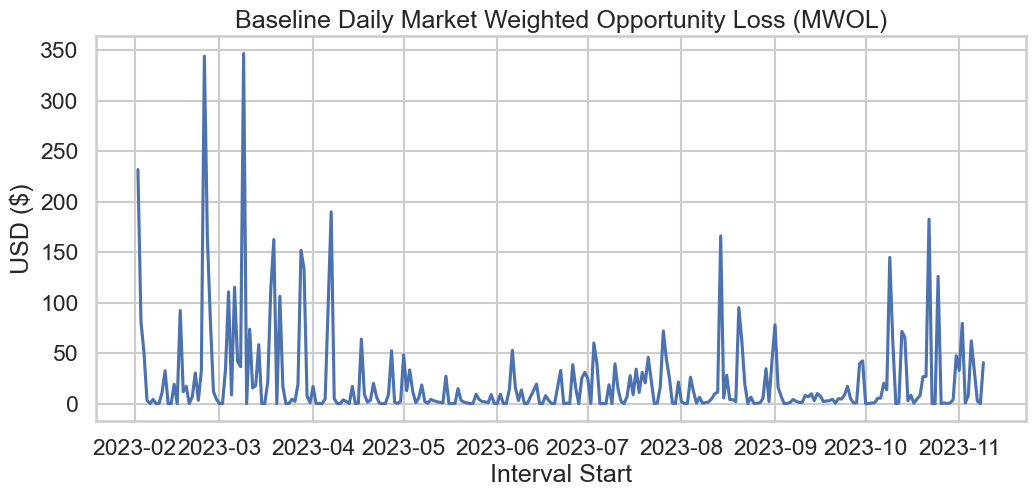

In [18]:
import pandas as pd
import numpy as np

def compute_market_weighted_loss(actuals_15min, preds_15min, lmp_df, time_col="measured_on"):
    # --- Nested Helper Function ---
    def meter_to_hourly_scaled(df, time_col="measured_on", scale=0.001*0.25):
        df = df.copy()
        df[time_col] = pd.to_datetime(df[time_col]).dt.tz_localize(None) 
        df = df.sort_values(time_col)
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        df[num_cols] = df[num_cols] * scale
        hourly_num = df.set_index(time_col)[num_cols].resample("1h").sum(min_count=1)
        return hourly_num.reset_index()

    # 1. Downsample to Hourly (kWh -> MWh)
    actuals_hourly = meter_to_hourly_scaled(actuals_15min, time_col=time_col)
    preds_hourly = meter_to_hourly_scaled(preds_15min, time_col=time_col)
    
    # 2. Align Data
    df = lmp_df.copy()
    df['Interval Start'] = pd.to_datetime(df['Interval Start']).dt.tz_localize(None)
    df = df.merge(actuals_hourly, left_on='Interval Start', right_on=time_col, how='left')
    df = df.merge(preds_hourly, left_on='Interval Start', right_on=time_col, how='left', suffixes=('_act', '_pred'))

    # 3. Filter for Data Presence & Calculate Imbalance Loss
    act_col = [c for c in actuals_hourly.columns if c != time_col][0]
    pred_col = [c for c in preds_hourly.columns if c != time_col][0]
    
    # Drop rows missing any of the three keys
    df = df.dropna(subset=['LMP', act_col, pred_col])

    # NEW LOGIC: Penalty = max(0, Price * (Predicted - Actual))
    # This covers Positive Price/Over-prediction AND Negative Price/Under-prediction
    df['mwol_penalty'] = np.maximum(0, df['LMP'] * (df[pred_col] - df[act_col]))
    
    # Potential Revenue remains max(0, Price * Actual)
    df['potential_revenue'] = np.maximum(0, df['LMP'] * df[act_col])

    # 4. Daily Aggregation
    daily_df = df.groupby(df['Interval Start'].dt.date).agg({
        'mwol_penalty': 'sum',
        'potential_revenue': 'sum'
    })

    # 5. Calculate Metrics
    total_loss = daily_df['mwol_penalty'].sum()
    total_potential = daily_df['potential_revenue'].sum()
    mean_daily_mwol = daily_df['mwol_penalty'].mean()
    efficiency = (1 - (total_loss / total_potential)) * 100 if total_potential > 0 else 0

    return {
        "Total MWOL ($)": total_loss,
        "Mean Daily MWOL ($/day)": mean_daily_mwol,
        "Financial Efficiency (%)": efficiency,
        "Daily_MWOL_Series": daily_df['mwol_penalty'],
        "Detailed_DF": df
    }


# Usage:
# results = compute_market_weighted_loss(meter_train, predictions_15min, lmp_df)
# print(f"Financial Efficiency: {results['Financial Efficiency (%)']:.2f}%")


baseline_results = compute_market_weighted_loss(
    meter_train[["measured_on", "meter_revenue_grade_ac_output_meter_149578"]], 
    meter_train[["measured_on", "yhat_baseline"]], 
    lmp_df, 
    time_col="measured_on"
)

# Plotting the daily trend
baseline_results['Daily_MWOL_Series'].plot(
    figsize=(12, 5), 
    title="Baseline Daily Market Weighted Opportunity Loss (MWOL)",
    ylabel="USD ($)"
)

# Access the results
print(f"Total MWOL: ${baseline_results['Total MWOL ($)']:,.2f}")
# Mean Daily MWOL (the dollar value lost per day on average)
print(f"Mean Daily MWOL: ${baseline_results['Mean Daily MWOL ($/day)']:,.2f}/day")
print(f"Financial Efficiency: {baseline_results['Financial Efficiency (%)']:.2f}%")

In [21]:
baseline_results['Detailed_DF']

,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss,measured_on_act,meter_revenue_grade_ac_output_meter_149578,measured_on_pred,yhat_baseline,mwol_penalty,potential_revenue
0,2023-02-02 00:00:00-08:00,2023-02-02 00:00:00,2023-02-02 01:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,136.84110,142.40930,0.00000,-5.56820,2023-02-02 00:00:00,0.0,2023-02-02 00:00:00,0.0,0.0,0.0
1,2023-02-02 01:00:00-08:00,2023-02-02 01:00:00,2023-02-02 02:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,136.57455,142.16151,0.00000,-5.58695,2023-02-02 01:00:00,0.0,2023-02-02 01:00:00,0.0,0.0,0.0
2,2023-02-02 02:00:00-08:00,2023-02-02 02:00:00,2023-02-02 03:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,132.91270,138.19162,0.00000,-5.27892,2023-02-02 02:00:00,0.0,2023-02-02 02:00:00,0.0,0.0,0.0
3,2023-02-02 03:00:00-08:00,2023-02-02 03:00:00,2023-02-02 04:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,137.52002,142.89279,0.00000,-5.37277,2023-02-02 03:00:00,0.0,2023-02-02 03:00:00,0.0,0.0,0.0
4,2023-02-02 04:00:00-08:00,2023-02-02 04:00:00,2023-02-02 05:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,144.05095,149.94373,0.00000,-5.89279,2023-02-02 04:00:00,0.0,2023-02-02 04:00:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6739,2023-11-09 19:00:00-08:00,2023-11-09 19:00:00,2023-11-09 20:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,80.57356,84.45813,-1.51974,-2.36483,2023-11-09 19:00:00,0.0,2023-11-09 19:00:00,0.0,0.0,0.0
6740,2023-11-09 20:00:00-08:00,2023-11-09 20:00:00,2023-11-09 21:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,80.76181,84.05110,-1.15439,-2.13490,2023-11-09 20:00:00,0.0,2023-11-09 20:00:00,0.0,0.0,0.0
6741,2023-11-09 21:00:00-08:00,2023-11-09 21:00:00,2023-11-09 22:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,79.67388,80.82671,-1.15283,0.00000,2023-11-09 21:00:00,0.0,2023-11-09 21:00:00,0.0,0.0,0.0
6742,2023-11-09 22:00:00-08:00,2023-11-09 22:00:00,2023-11-09 23:00:00-08:00,DAY_AHEAD_HOURLY,TH_NP15_GEN-APND,Trading Hub,74.05524,76.53918,-0.57811,-1.90583,2023-11-09 22:00:00,0.0,2023-11-09 22:00:00,0.0,0.0,0.0


Let's also plot the daily MWOL for linear regression and random forest.

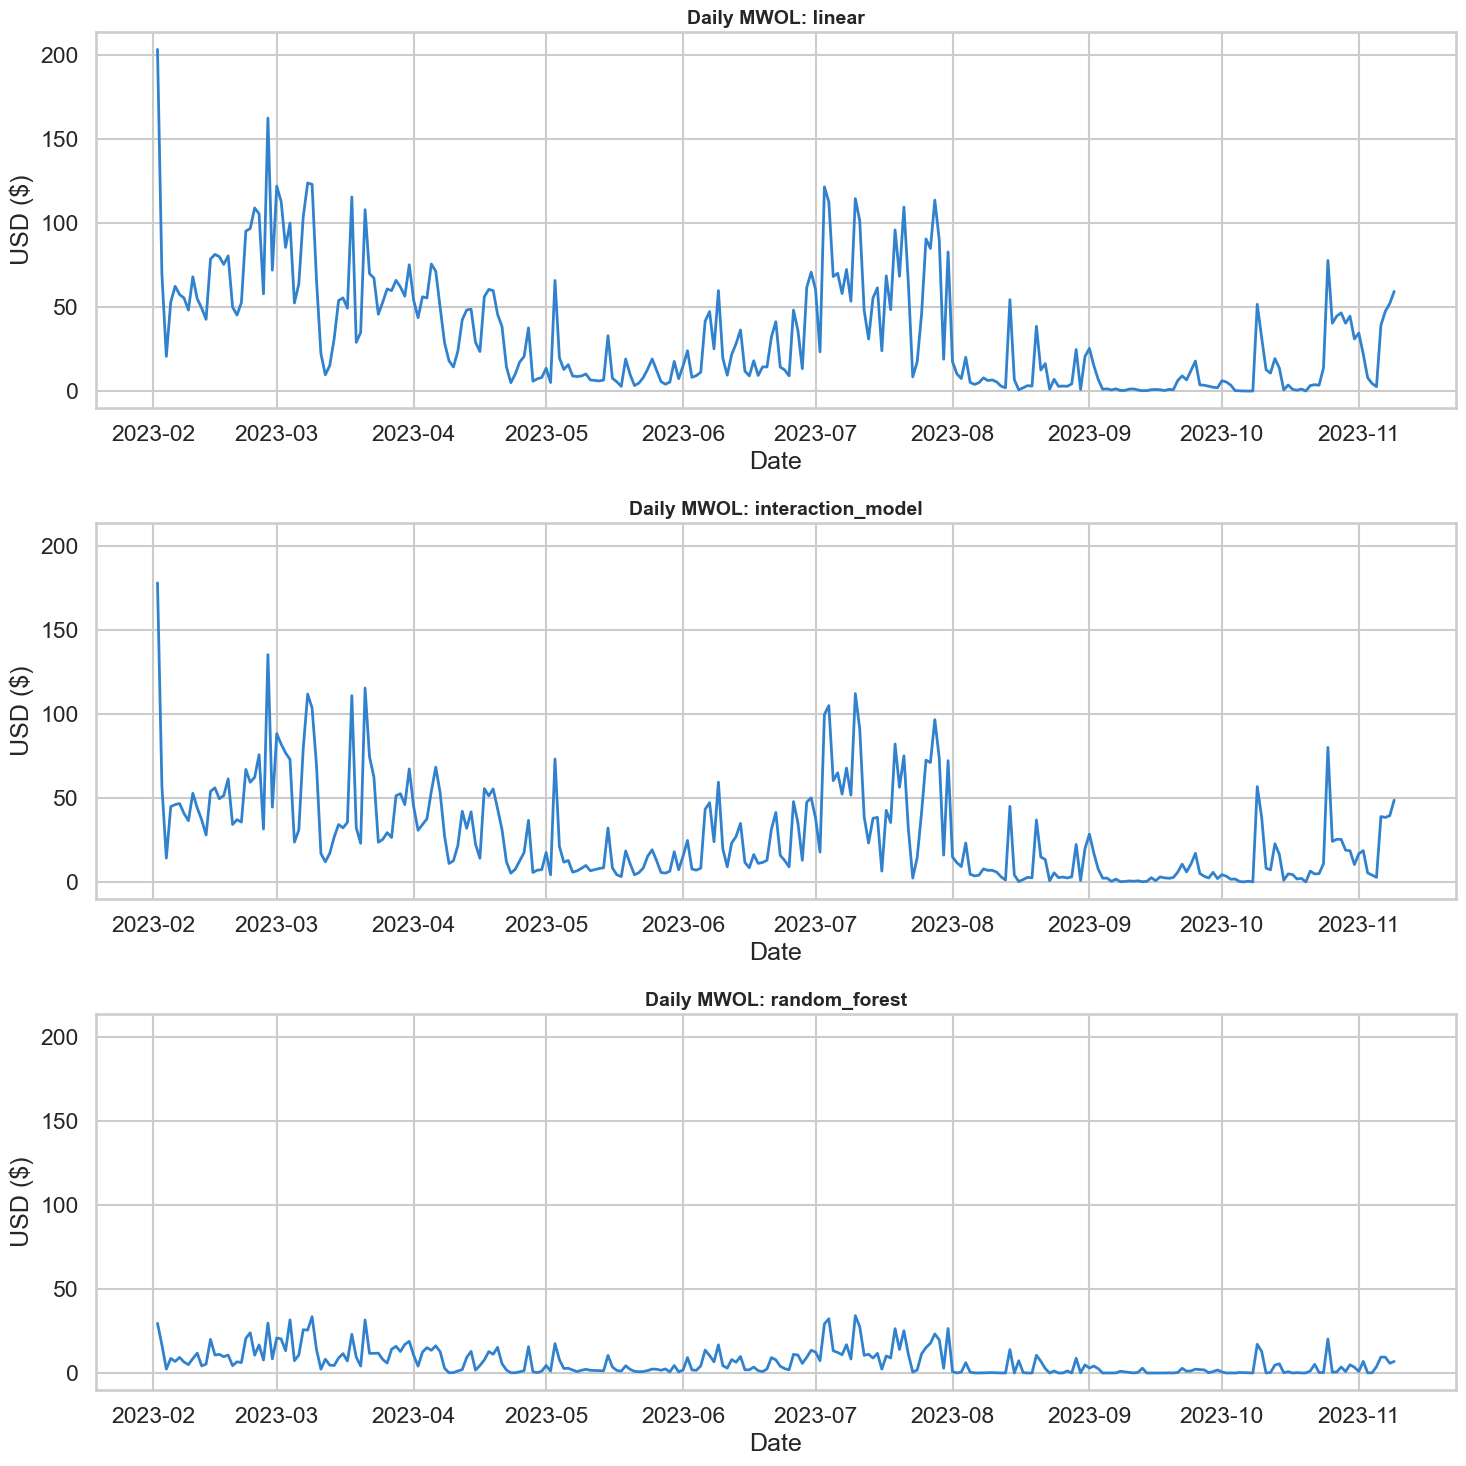

In [25]:
# make a plot of daily MWOL for model

fig, axes = plt.subplots(len(models), 1, figsize=(15,15), sharey=True)

# Flatten axes so it works perfectly whether you have 1, 2, or 3+ models
if len(models) == 1:
    axes_flat = [axes]
else:
    axes_flat = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    actuals_input = df_train[["measured_on", target]]
    preds_input = pd.DataFrame({
        "measured_on": df_train["measured_on"], 
        "prediction": model.predict(df_train[feature_cols])
    })
    results = compute_market_weighted_loss(actuals_input,
                                          preds_input,
                                            lmp_df,
                                            time_col="measured_on")
    
    sns.lineplot(data=results['Daily_MWOL_Series'], linewidth=2, ax=axes_flat[i], color="#3182ce")

    # Personalize each subplot so you know which model is which
    axes_flat[i].set_title(f"Daily MWOL: {name}", fontsize=14, weight="bold")
    axes_flat[i].set_ylabel("USD ($)")
    axes_flat[i].set_xlabel("Date")

# Clean up layout adjustments and show the final stacked plots
plt.tight_layout()
plt.show()